# Agent Supervisor

![](https://d.pr/i/gKezSO+)

In [2]:
%pip install -Uqqq langchain-experimental langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 도구 생성

In [ ]:
from langchain_tavily import TavilySearch  # Tavily 웹 검색
from langchain_experimental.tools import PythonREPLTool  # 파이썬 코드 실행 Tool

tavily_tool = TavilySearch(max_results=3)
python_repl_tool = PythonREPLTool()

In [5]:
# 에이전트 노드 실행기 : 각 에이전트 답변을 사람메시지로 재가공하는 헬퍼 함수
from langchain_core.messages import HumanMessage

# 에이전트를 실행하고, 마지막 ai 응답을 HumanMessage로 감싸 반환하는 함수
def agent_node(state, agent, name):
    response = agent.invoke(state)
    # 마지막 응답은 지정된 name의 HumanMessage 형태로 반환
    return {'messages': [HumanMessage(content=response['messages'][-1].content, name=name)]}

## Supervisor Agent 구성
- 다음 작업자 (Researcher / Coder / FINISH) 결정

In [16]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder  # 중간 대화 삽입
from langchain.chat_models import init_chat_model
from pydantic import BaseModel  # 구조화 출력
from typing import Literal      # 값 제한

members = ['Researcher', 'Coder']  # 하위 에이전트
system_prompt = """  # Supervisor 역할/지침(system) 프롬프트
다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."
"""

llm = init_chat_model('gpt-5.4-mini')

options = members + ['FINISH']  # Supervisor의 선택지

# Supervisor 응답은 구조화된 형태
class RouteResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"]  # 다음 행동은 3개 중 하나로 제한

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name = 'messages'),  # 지금까지의 대화 내용 추가
    ('system', '''
위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음중 하나를 선택하세요: {options}
    ''')
]).partial(options=options, members=', '.join(members))  # partial : options/members 미리 고정

# 현재까지의 대화내용을 확인하여 다음 작업자를 라우팅해주는 Supervisor 함수
def supervisor_agent(state):
    # 프롬프트 + LLM의 응답을 RouteResponse 파싱
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    return supervisor_chain.invoke(state)  # next값 반환

## Graph 조립

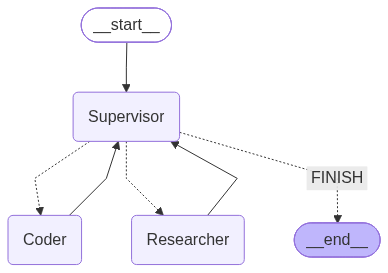

In [17]:
from typing import TypedDict, Annotated, List        # 상태 타입 정의
from langgraph.graph import StateGraph, START, END   # Langgraph 구성요소
from langgraph.graph.message import add_messages     # Messages 누적 처리 유틸
from langchain_core.messages import BaseMessage      # Messages 타입 힌트 정의
from langchain.agents import create_agent            # Tool 사용하는 에이전트
import functools  # partial 사용 (값을 미리 고정)

# 그래프에서 사용할 상태 스키마 커스터마이징
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]  # messages는 add_messages의 규칙으로 누적
    next: str  # Supervisor가 결정한 다음 노드

research_agent = create_agent(llm, tools=[tavily_tool])
# functools.partial() : 기존함수의 일부 인자를 미리 채운 함수를 반환 
# agent_node에 agent/name을 미리 정해줌
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')

workflow = StateGraph(AgentState)

# 노드
workflow.add_node('Supervisor', supervisor_agent)
workflow.add_node('Researcher', research_node)
workflow.add_node('Coder', code_node)

# 엣지
workflow.add_edge(START, 'Supervisor')
workflow.add_edge('Researcher', 'Supervisor')
workflow.add_edge('Coder', 'Supervisor')

conditional_map = {member: member for member in members}  # {'Researcher': 'Researcher', ...}
conditional_map['FINISH'] = END

# state['next'] 기준에 따라 조건 분기 추가
workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)

graph = workflow.compile()  # 그래프 컴파일
graph

In [ ]:
# 노드별 출력
for chunk in graph.stream({
    'messages': [
        ('human', '파이썬 HelloWorld 출력하는 코드를 작성하고, 콘솔에 출력해줘!')
    ]
}):
    print(chunk)  # 노드 메시지 출력

{'Supervisor': {'next': 'Coder'}}
{'Coder': {'messages': [HumanMessage(content='```python\nprint("Hello, World!")\n```\n\n콘솔 출력 결과:\n```text\nHello, World!\n```', additional_kwargs={}, response_metadata={}, name='Coder', id='b97bfeb8-31e0-473c-99be-f3b778365e01')]}}
{'Supervisor': {'next': 'FINISH'}}


{'Supervisor': {'next': 'Coder'}}


Python REPL can execute arbitrary code. Use with caution.


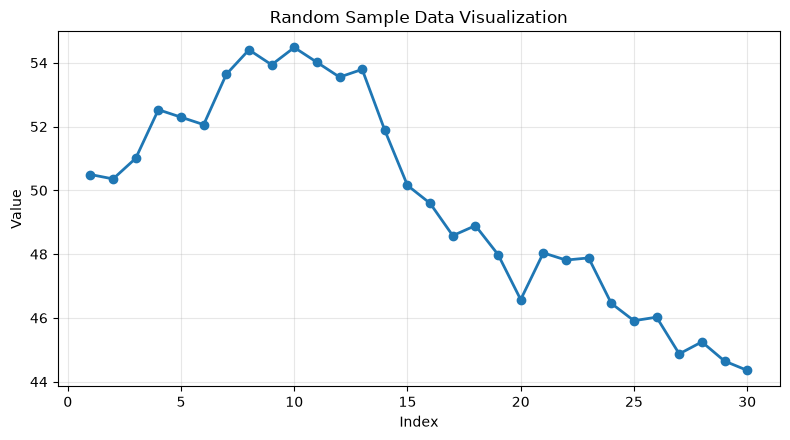

{'Coder': {'messages': [HumanMessage(content='임의의 데이터를 matplotlib로 시각화했습니다.  \n원하시면 다음처럼 바꿔서 다시 그려드릴 수 있어요:\n\n- 선그래프 대신 막대그래프 / 산점도\n- 더 많은 데이터 포인트\n- 한글 제목/축 라벨\n- 색상/스타일 변경\n- 여러 개의 데이터 시리즈 비교', additional_kwargs={}, response_metadata={}, name='Coder', id='4b469c9b-4080-4ee4-9025-4ef1823a9acc')]}}
{'Supervisor': {'next': 'FINISH'}}


In [23]:
# 노드별 출력
for chunk in graph.stream({
    'messages': [
        ('human', '임의의 데이터를 matplotlib으로 시각화 진행해줘. 코드로 주지말고 도구를 사용해서 직접 해줘')
    ]
}):
    print(chunk)  # 노드 메시지 출력

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content="아래는 **질병관리청 감염병포털(KDCA)**의 공개 요약 수치를 바탕으로, **대한민국 코로나19 연도별 감염자 수**를 `matplotlib`으로 시각화하는 예시 레포트입니다.  \n※ 다만 KDCA 페이지에서 제공되는 연도별 수치는 **2023년 8월 31일까지의 전수감시 집계**입니다. 따라서 2023년 값은 **연간 전체가 아니라 8월 31일까지 누적**입니다.\n\n---\n\n## 연도별 감염자 수 데이터\n출처: KDCA 감염병포털  \n- 2020: 60,722\n- 2021: 569,943\n- 2022: 28,424,349\n- 2023(8/31까지): 5,517,540\n\n합계: 34,572,554\n\n---\n\n## Python 코드 (matplotlib 시각화)\n\n```python\nimport matplotlib.pyplot as plt\n\n# 데이터\nyears = ['2020', '2021', '2022', '2023(8/31)']\ncases = [60722, 569943, 28424349, 5517540]\n\n# 한글 폰트 설정(환경에 따라 하나만 동작)\nplt.rcParams['font.family'] = 'Malgun Gothic'   # Windows\nplt.rcParams['axes.unicode_minus'] = False\n\n# 그래프\nplt.figure(figsize=(10, 6))\nbars = plt.bar(years, cases, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])\n\n# 값 라벨 추가\nfor bar, value in zip(bars, cases):\n    plt.text(\n        bar.get_x() + bar.get_width() / 2,\n        b

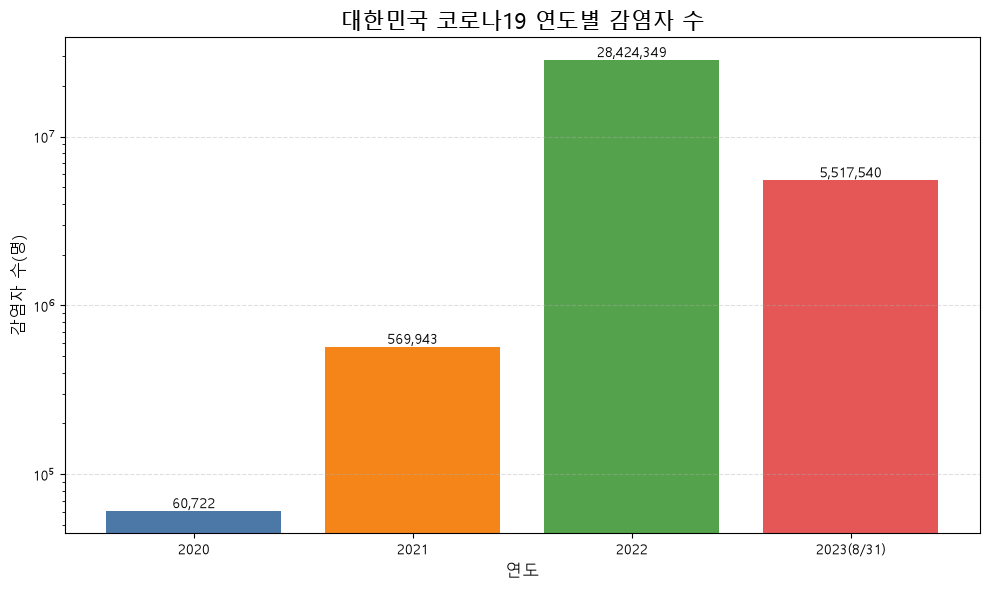

In [28]:
# 노드별 출력
for chunk in graph.stream({
    'messages': [
        ('human', '대한민국 코로나 연도별 감염자 수를 matplotlib으로 시각화해줘. 도구를 사용해서 레포트를 직접 생성해줘')
    ]
}):
    print(chunk)  # 노드 메시지 출력